In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import medfilt, wiener

In [2]:
sns.set()

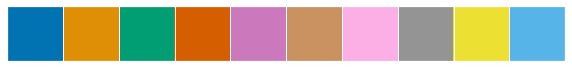

In [3]:
colors = sns.color_palette("colorblind")
sns.palplot(colors)

In [4]:
def get_metrics(fn):
    metrics = {"training_losses":[],
                 "validation_losses":[],
                 "accuracy":[],
                 "balanced_accuracy":[]}
    with open(fn) as f_pos:
        lines = f_pos.readlines()
        for l in lines:
            if l[0] == 'T':
                c = l.split()
                metrics["training_losses"].append(float(c[4].strip(',')))
            elif l[0] == 'V':
                c = l.split()
                metrics["validation_losses"].append(float(c[4].strip(',')))
                metrics["accuracy"].append(float(c[6].strip(',')))
                metrics["balanced_accuracy"].append(float(c[8].strip(',')))
                
    return metrics

In [5]:
positives = get_metrics("../diabnet/logs/model-sp-soft-label-positives-1000.log")

In [6]:
negatives = get_metrics("../diabnet/logs/model-sp-soft-label-negatives-1000.log")

In [7]:
random  = get_metrics("../diabnet/logs/model-sp-soft-label-random-1000.log")

In [13]:
pos_decay  = get_metrics("../diabnet/logs/model-sp-soft-label-positives-1000-decay.log")

FileNotFoundError: [Errno 2] No such file or directory: '../diabnet/logs/model-sp-soft-label-positives-1000-decay.log'

(0.4, 0.9)

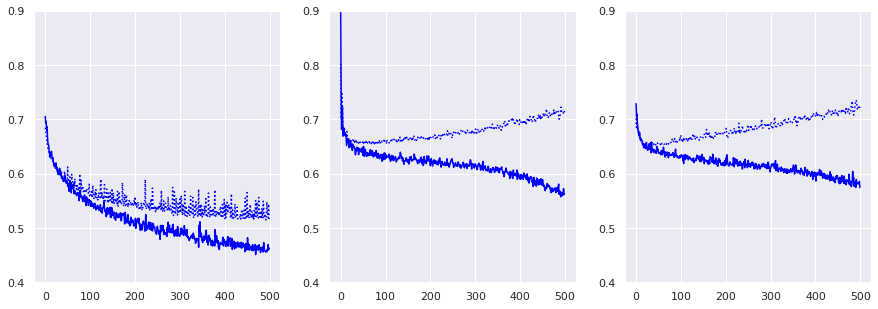

In [8]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(positives["training_losses"], color='blue')
plt.plot(positives["validation_losses"], color='blue', ls=':')
plt.ylim(0.4,0.9)
plt.subplot(132)
plt.plot(negatives["training_losses"], color='blue')
plt.plot(negatives["validation_losses"], color='blue', ls=':')
plt.ylim(0.4,0.9)
plt.subplot(133)
plt.plot(random["training_losses"], color='blue')
plt.plot(random["validation_losses"], color='blue', ls=':')
plt.ylim(0.4,0.9)

(0.4, 1.0)

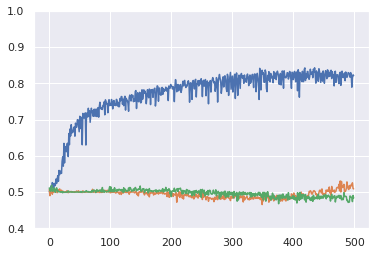

In [10]:
plt.plot(positives["balanced_accuracy"])
plt.plot(negatives["balanced_accuracy"])
plt.plot(random["balanced_accuracy"])
plt.ylim(0.4,1.0)

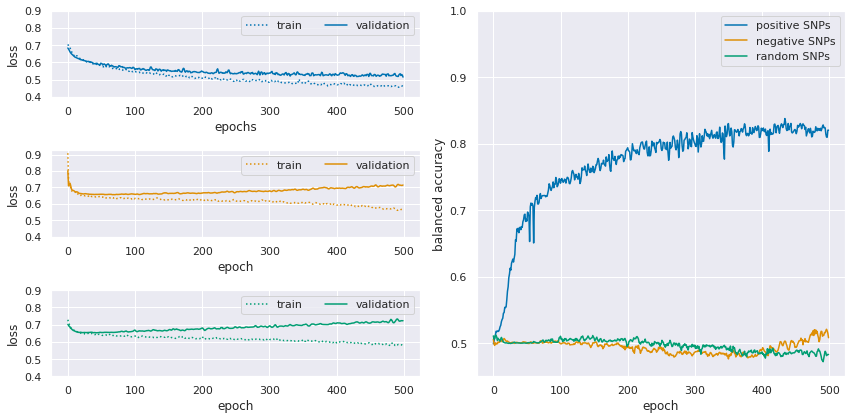

In [12]:
plt.figure(figsize=(12,6))
plt.subplot(321)
line_t = plt.plot(wiener(positives["training_losses"]), color=colors[0], ls=':', label="train")
line_v = plt.plot(wiener(positives["validation_losses"]), color=colors[0], label="validation")
plt.legend( loc='upper right',ncol=2)
plt.xlabel("epochs")
plt.ylabel("loss")
# plt.ylim(0.42,0.9)
plt.yticks(np.arange(0.4,1.0,0.1))
plt.subplot(323)
plt.plot(wiener(negatives["training_losses"]), color=colors[1], ls=':', label="train")
plt.plot(wiener(negatives["validation_losses"]), color=colors[1], label="validation")
plt.legend( loc='upper right',ncol=2)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.yticks(np.arange(0.4,1.0,0.1))
plt.subplot(325)
plt.plot(wiener(random["training_losses"]), color=colors[2], ls=':', label="train")
plt.plot(wiener(random["validation_losses"]), color=colors[2], label="validation")
plt.legend( loc='upper right',ncol=2)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.yticks(np.arange(0.4,1.0,0.1))
plt.subplot(122)
plt.plot(wiener(positives["balanced_accuracy"]), color=colors[0], label="positive SNPs")
plt.plot(wiener(negatives["balanced_accuracy"]), color=colors[1], label="negative SNPs")
plt.plot(wiener(random["balanced_accuracy"]), color=colors[2], label="random SNPs")
plt.legend( loc='upper right')
plt.xlabel("epoch")
plt.ylabel("balanced accuracy")
plt.ylim(0.45,1.0)
plt.tight_layout()
plt.savefig("training_results.png")

In [88]:
sns.xkcd_rgb

{'acid green': '#8ffe09',
 'adobe': '#bd6c48',
 'algae': '#54ac68',
 'algae green': '#21c36f',
 'almost black': '#070d0d',
 'amber': '#feb308',
 'amethyst': '#9b5fc0',
 'apple': '#6ecb3c',
 'apple green': '#76cd26',
 'apricot': '#ffb16d',
 'aqua': '#13eac9',
 'aqua blue': '#02d8e9',
 'aqua green': '#12e193',
 'aqua marine': '#2ee8bb',
 'aquamarine': '#04d8b2',
 'army green': '#4b5d16',
 'asparagus': '#77ab56',
 'aubergine': '#3d0734',
 'auburn': '#9a3001',
 'avocado': '#90b134',
 'avocado green': '#87a922',
 'azul': '#1d5dec',
 'azure': '#069af3',
 'baby blue': '#a2cffe',
 'baby green': '#8cff9e',
 'baby pink': '#ffb7ce',
 'baby poo': '#ab9004',
 'baby poop': '#937c00',
 'baby poop green': '#8f9805',
 'baby puke green': '#b6c406',
 'baby purple': '#ca9bf7',
 'baby shit brown': '#ad900d',
 'baby shit green': '#889717',
 'banana': '#ffff7e',
 'banana yellow': '#fafe4b',
 'barbie pink': '#fe46a5',
 'barf green': '#94ac02',
 'barney': '#ac1db8',
 'barney purple': '#a00498',
 'battleship gr

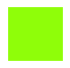

In [93]:
sns.palplot(sns.xkcd_palette(['acid green']))